In [4]:
# ============================================
# Notebook: Statistical Analysis
# Project: RGV Business Survival Predictor
# Topics: Parameters & Likelihood, Hypothesis Testing,
#         Permutation Tests, Correlations, Mutual Info
# ============================================

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder

drive.mount('/content/drive')
MERGED = '/content/drive/MyDrive/rgv_business_survival/data/merged'

model_df = pd.read_csv(f'{MERGED}/model_df.csv')
print(f"Loaded: {model_df.shape}")
model_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: (8119, 16)


,borrname,borrcity,borrzip,grossapproval,sbaguaranteedapproval,approvalfiscalyear,initialinterestrate,terminmonths,naicscode,naicsdescription,businesstype,businessage,loanstatus,defaulted,jobssupported,projectcounty
0,Elite Sprinkler Services,KATY,77450,15000,7500.0,2018,10.00,120,238220.0,"Plumbing, Heating, and Air-Conditioning Contra...",INDIVIDUAL,Unanswered,PIF,0,2.0,HARRIS
1,Tax2Go LLC,Desoto,75115,125000,106250.0,2018,7.25,120,541213.0,Tax Preparation Services,CORPORATION,Existing or more than 2 years old,PIF,0,2.0,DALLAS
2,Upstairs Circus Atx LLC,Austin,78701,455000,341250.0,2018,6.50,120,722410.0,Drinking Places (Alcoholic Beverages),CORPORATION,Unknown,PIF,0,12.0,TRAVIS
3,BARGE INVESTMENTS INC.,LONGVIEW,75605,200000,150000.0,2018,7.25,123,441310.0,Automotive Parts and Accessories Stores,CORPORATION,"Startup, Loan Funds will Open Business",PIF,0,4.0,GREGG
4,PP9A LLC,BAYTOWN,77523,40000,20000.0,2018,7.85,60,561790.0,Other Services to Buildings and Dwellings,CORPORATION,Existing or more than 2 years old,PIF,0,5.0,CHAMBERS


In [5]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8119 entries, 0 to 8118
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   borrname               8119 non-null   object 
 1   borrcity               8119 non-null   object 
 2   borrzip                8119 non-null   int64  
 3   grossapproval          8119 non-null   int64  
 4   sbaguaranteedapproval  8119 non-null   float64
 5   approvalfiscalyear     8119 non-null   int64  
 6   initialinterestrate    8119 non-null   float64
 7   terminmonths           8119 non-null   int64  
 8   naicscode              8119 non-null   float64
 9   naicsdescription       8119 non-null   object 
 10  businesstype           8119 non-null   object 
 11  businessage            8119 non-null   object 
 12  loanstatus             8119 non-null   object 
 13  defaulted              8119 non-null   int64  
 14  jobssupported          8119 non-null   float64
 15  proj

In [6]:
# ============================================
# COLUMN MAPPING
# ============================================

TARGET       = 'defaulted'        # 1 = defaulted, 0 = survived
INDUSTRY_COL = 'naicsdescription'
LOAN_COL     = 'grossapproval'

NUMERIC_COLS = [
    'grossapproval',
    'sbaguaranteedapproval',
    'initialinterestrate',
    'terminmonths',
    'jobssupported',
    'approvalfiscalyear'
]

CATEGORICAL_COLS = [
    'naicsdescription',
    'businesstype',
    'businessage',
    'borrcity',
    'projectcounty'
]

   MLE Estimate of Default/Survival Probability
  Total businesses:      8,119
  Survived (defaulted=0): 7,140
  Defaulted (defaulted=1): 979
  p̂ default rate (MLE):  0.1206  (12.1%)
  p̂ survival rate:       0.8794  (87.9%)
  95% CI (default rate): (0.1135, 0.1277)


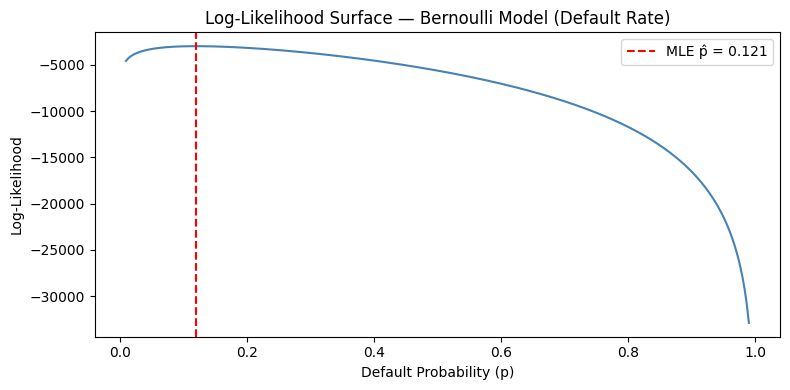

In [7]:
# ============================================
# SECTION 1: Parameters & Likelihood
# Goal: Estimate default rate and model it
#       as a Bernoulli/Binomial distribution
# ============================================

default_rate = model_df[TARGET].mean()
survival_rate = 1 - default_rate
n = len(model_df)

print("=" * 50)
print("   MLE Estimate of Default/Survival Probability")
print("=" * 50)
print(f"  Total businesses:      {n:,}")
print(f"  Survived (defaulted=0): {(model_df[TARGET] == 0).sum():,}")
print(f"  Defaulted (defaulted=1): {model_df[TARGET].sum():,}")
print(f"  p̂ default rate (MLE):  {default_rate:.4f}  ({default_rate*100:.1f}%)")
print(f"  p̂ survival rate:       {survival_rate:.4f}  ({survival_rate*100:.1f}%)")

# 95% Confidence Interval for default rate
se = np.sqrt(default_rate * (1 - default_rate) / n)
ci_low  = default_rate - 1.96 * se
ci_high = default_rate + 1.96 * se
print(f"  95% CI (default rate): ({ci_low:.4f}, {ci_high:.4f})")

# --- Log-Likelihood surface ---
p_range = np.linspace(0.01, 0.99, 300)
log_likelihood = (model_df[TARGET].sum() * np.log(p_range) +
                  (n - model_df[TARGET].sum()) * np.log(1 - p_range))

plt.figure(figsize=(8, 4))
plt.plot(p_range, log_likelihood, color='steelblue')
plt.axvline(default_rate, color='red', linestyle='--',
            label=f'MLE p̂ = {default_rate:.3f}')
plt.xlabel('Default Probability (p)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Surface — Bernoulli Model (Default Rate)')
plt.legend()
plt.tight_layout()
plt.show()

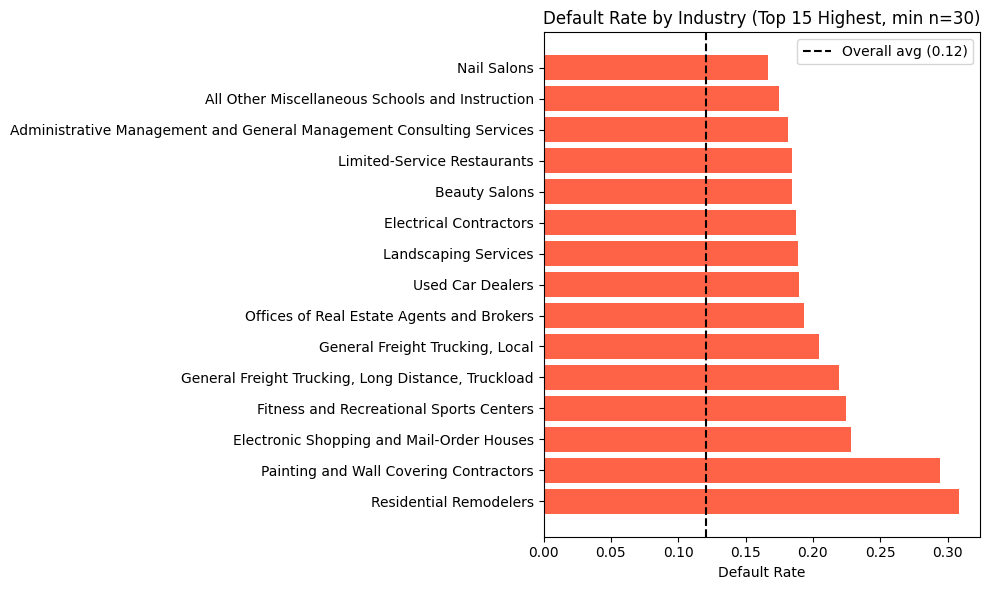

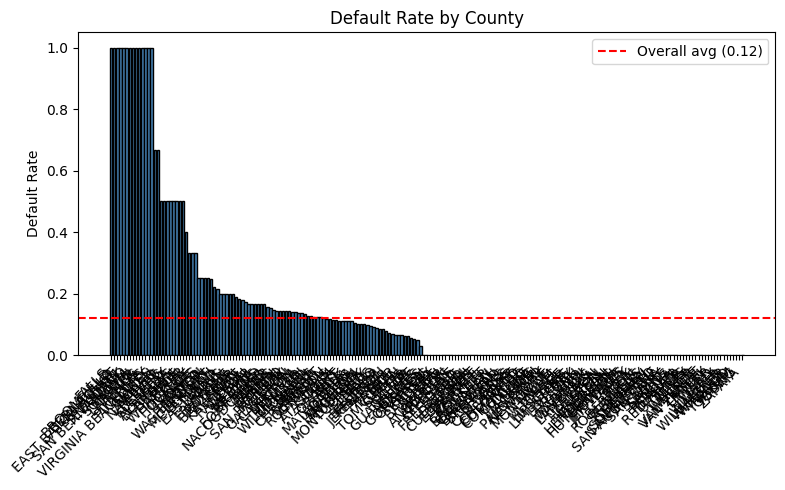

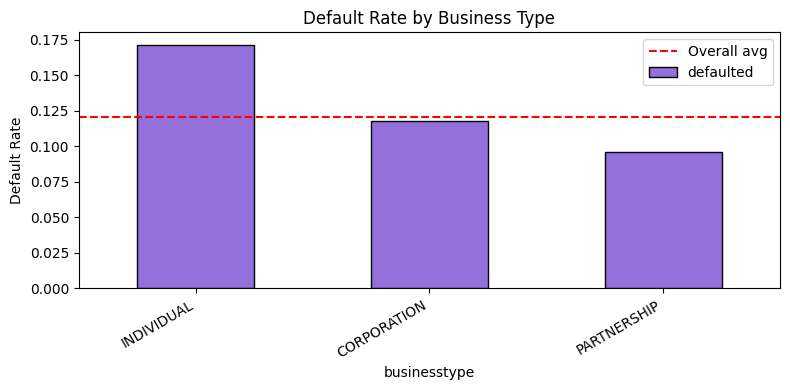

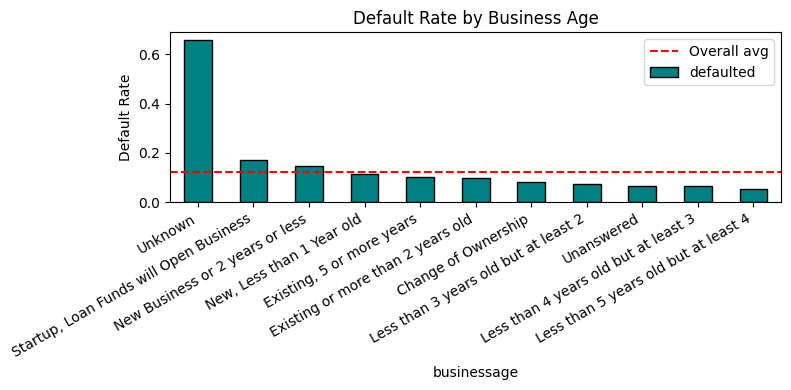

/tmp/ipykernel_22367/4250973329.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_default = model_df.groupby('loan_bucket')[TARGET].mean()


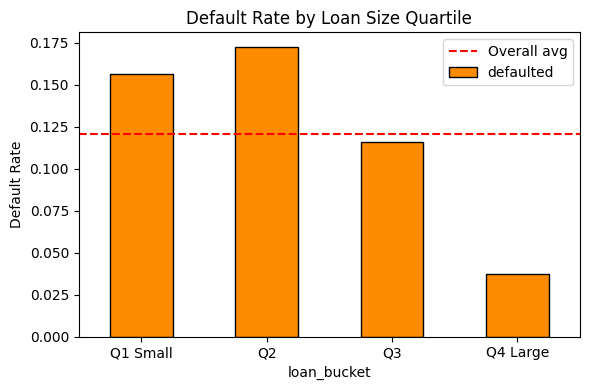

In [8]:
# ============================================
# SECTION 2: Differential Analysis
# Goal: Compare default rates across groups
#       (industry, county, loan size bucket)
# ============================================

# --- Default rate by industry (top 15 highest default) ---
industry_default = (
    model_df.groupby(INDUSTRY_COL)[TARGET]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n'})
    .query('n >= 30')
    .sort_values('default_rate', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.barh(industry_default.index, industry_default['default_rate'], color='tomato')
plt.axvline(default_rate, color='black', linestyle='--',
            label=f'Overall avg ({default_rate:.2f})')
plt.xlabel('Default Rate')
plt.title('Default Rate by Industry (Top 15 Highest, min n=30)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Default rate by county ---
county_default = (
    model_df.groupby('projectcounty')[TARGET]
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n'})
    .sort_values('default_rate', ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(county_default.index, county_default['default_rate'],
        color='steelblue', edgecolor='black')
plt.axhline(default_rate, color='red', linestyle='--',
            label=f'Overall avg ({default_rate:.2f})')
plt.ylabel('Default Rate')
plt.title('Default Rate by County')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Default rate by business type ---
btype_default = model_df.groupby('businesstype')[TARGET].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
btype_default.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.axhline(default_rate, color='red', linestyle='--', label='Overall avg')
plt.ylabel('Default Rate')
plt.title('Default Rate by Business Type')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Default rate by business age ---
age_default = model_df.groupby('businessage')[TARGET].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
age_default.plot(kind='bar', color='teal', edgecolor='black')
plt.axhline(default_rate, color='red', linestyle='--', label='Overall avg')
plt.ylabel('Default Rate')
plt.title('Default Rate by Business Age')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Loan size buckets ---
model_df['loan_bucket'] = pd.qcut(model_df[LOAN_COL], q=4,
                                   labels=['Q1 Small', 'Q2', 'Q3', 'Q4 Large'])
loan_default = model_df.groupby('loan_bucket')[TARGET].mean()

plt.figure(figsize=(6, 4))
loan_default.plot(kind='bar', color='darkorange', edgecolor='black')
plt.axhline(default_rate, color='red', linestyle='--', label='Overall avg')
plt.ylabel('Default Rate')
plt.title('Default Rate by Loan Size Quartile')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# SECTION 3: Hypothesis Testing
# Goal: Test whether default rates differ
#       significantly across groups
# ============================================

# --- Two-sample Z-test: Small loans vs Large loans ---
small = model_df[model_df['loan_bucket'] == 'Q1 Small'][TARGET]
large = model_df[model_df['loan_bucket'] == 'Q4 Large'][TARGET]

p1, n1 = small.mean(), len(small)
p2, n2 = large.mean(), len(large)
p_pool = (small.sum() + large.sum()) / (n1 + n2)

z_stat = (p1 - p2) / np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("=" * 55)
print("  H0: Default rate is equal for small vs large loans")
print("  H1: Default rates differ")
print("=" * 55)
print(f"  Small loan default rate:  {p1:.4f}  (n={n1:,})")
print(f"  Large loan default rate:  {p2:.4f}  (n={n2:,})")
print(f"  Z-statistic:              {z_stat:.4f}")
print(f"  P-value:                  {p_value:.6f}")
print(f"  Significant (α=0.05):     {'YES ✓' if p_value < 0.05 else 'NO'}")

# --- Chi-Square: Industry vs Default outcome ---
contingency_industry = pd.crosstab(model_df[INDUSTRY_COL], model_df[TARGET])
chi2_ind, p_ind, dof_ind, _ = stats.chi2_contingency(contingency_industry)

print("\n" + "=" * 55)
print("  Chi-Square Test: Industry vs Default")
print("=" * 55)
print(f"  Chi2 statistic:       {chi2_ind:.2f}")
print(f"  Degrees of freedom:   {dof_ind}")
print(f"  P-value:              {p_ind:.6f}")
print(f"  Significant (α=0.05): {'YES ✓' if p_ind < 0.05 else 'NO'}")

# --- Chi-Square: Business Age vs Default outcome ---
contingency_age = pd.crosstab(model_df['businessage'], model_df[TARGET])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(contingency_age)

print("\n" + "=" * 55)
print("  Chi-Square Test: Business Age vs Default")
print("=" * 55)
print(f"  Chi2 statistic:       {chi2_age:.2f}")
print(f"  Degrees of freedom:   {dof_age}")
print(f"  P-value:              {p_age:.6f}")
print(f"  Significant (α=0.05): {'YES ✓' if p_age < 0.05 else 'NO'}")

# --- Chi-Square: Business Type vs Default outcome ---
contingency_btype = pd.crosstab(model_df['businesstype'], model_df[TARGET])
chi2_bt, p_bt, dof_bt, _ = stats.chi2_contingency(contingency_btype)

print("\n" + "=" * 55)
print("  Chi-Square Test: Business Type vs Default")
print("=" * 55)
print(f"  Chi2 statistic:       {chi2_bt:.2f}")
print(f"  Degrees of freedom:   {dof_bt}")
print(f"  P-value:              {p_bt:.6f}")
print(f"  Significant (α=0.05): {'YES ✓' if p_bt < 0.05 else 'NO'}")

  H0: Default rate is equal for small vs large loans
  H1: Default rates differ
  Small loan default rate:  0.1562  (n=2,030)
  Large loan default rate:  0.0375  (n=2,029)
  Z-statistic:              12.7867
  P-value:                  0.000000
  Significant (α=0.05):     YES ✓

  Chi-Square Test: Industry vs Default
  Chi2 statistic:       1003.68
  Degrees of freedom:   583
  P-value:              0.000000
  Significant (α=0.05): YES ✓

  Chi-Square Test: Business Age vs Default
  Chi2 statistic:       396.28
  Degrees of freedom:   10
  P-value:              0.000000
  Significant (α=0.05): YES ✓

  Chi-Square Test: Business Type vs Default
  Chi2 statistic:       13.97
  Degrees of freedom:   2
  P-value:              0.000924
  Significant (α=0.05): YES ✓


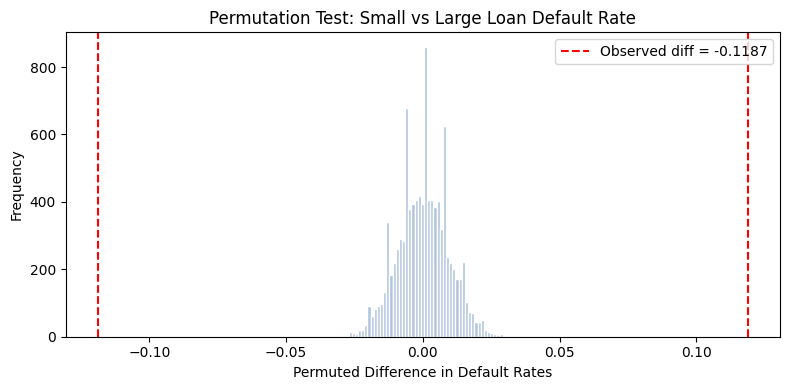

Observed difference:   -0.1187
Permutation p-value:   0.0000
Significant (α=0.05):  YES ✓


In [10]:
# ============================================
# SECTION 4: Permutation Test
# Goal: Non-parametric check — does loan size
#       truly affect default rate, or is it chance?
# ============================================

observed_diff = large.mean() - small.mean()

combined = np.concatenate([small.values, large.values])
n_permutations = 10_000
perm_diffs = []

rng = np.random.default_rng(seed=42)
for _ in range(n_permutations):
    shuffled = rng.permutation(combined)
    perm_diffs.append(shuffled[:n1].mean() - shuffled[n1:].mean())

perm_diffs = np.array(perm_diffs)
perm_p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

plt.figure(figsize=(8, 4))
plt.hist(perm_diffs, bins=60, color='lightsteelblue', edgecolor='white')
plt.axvline(observed_diff,  color='red', linestyle='--',
            label=f'Observed diff = {observed_diff:.4f}')
plt.axvline(-observed_diff, color='red', linestyle='--')
plt.xlabel('Permuted Difference in Default Rates')
plt.ylabel('Frequency')
plt.title('Permutation Test: Small vs Large Loan Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Observed difference:   {observed_diff:.4f}")
print(f"Permutation p-value:   {perm_p_value:.4f}")
print(f"Significant (α=0.05):  {'YES ✓' if perm_p_value < 0.05 else 'NO'}")

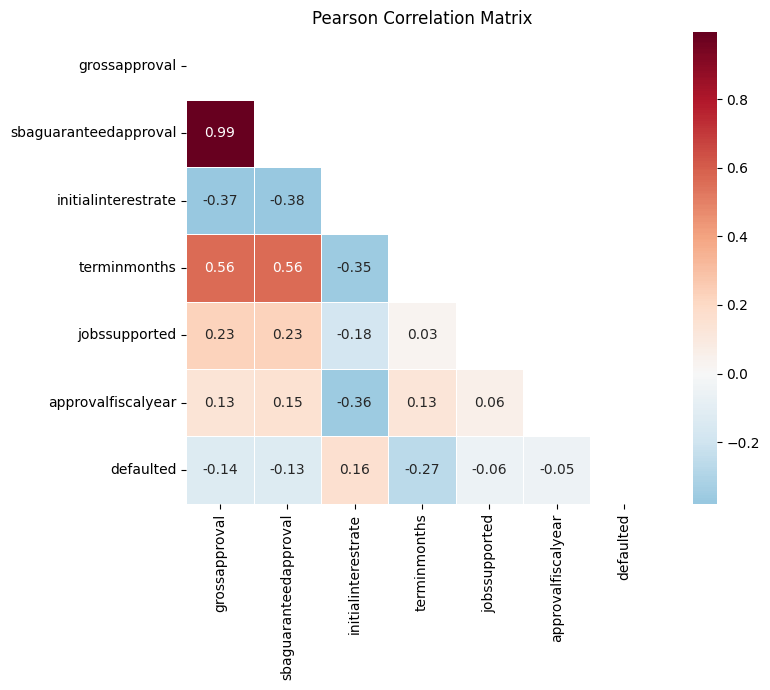


Point-Biserial Correlations with Default:
------------------------------------------------
  grossapproval                  r = -0.1353  p = 0.0000 ✓
  sbaguaranteedapproval          r = -0.1338  p = 0.0000 ✓
  initialinterestrate            r = +0.1584  p = 0.0000 ✓
  terminmonths                   r = -0.2711  p = 0.0000 ✓
  jobssupported                  r = -0.0556  p = 0.0000 ✓
  approvalfiscalyear             r = -0.0483  p = 0.0000 ✓


In [11]:
# ============================================
# SECTION 5: Correlations & Distance Measures
# Goal: Find which numeric features relate
#       most strongly to default outcome
# ============================================

# --- Pearson correlation matrix ---
corr_cols = NUMERIC_COLS + [TARGET]
corr_matrix = model_df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

# --- Point-biserial correlation with defaulted (best for binary target) ---
print("\nPoint-Biserial Correlations with Default:")
print("-" * 48)
for col in NUMERIC_COLS:
    r, p = stats.pointbiserialr(model_df[TARGET], model_df[col].fillna(0))
    sig = '✓' if p < 0.05 else ''
    print(f"  {col:<30} r = {r:+.4f}  p = {p:.4f} {sig}")

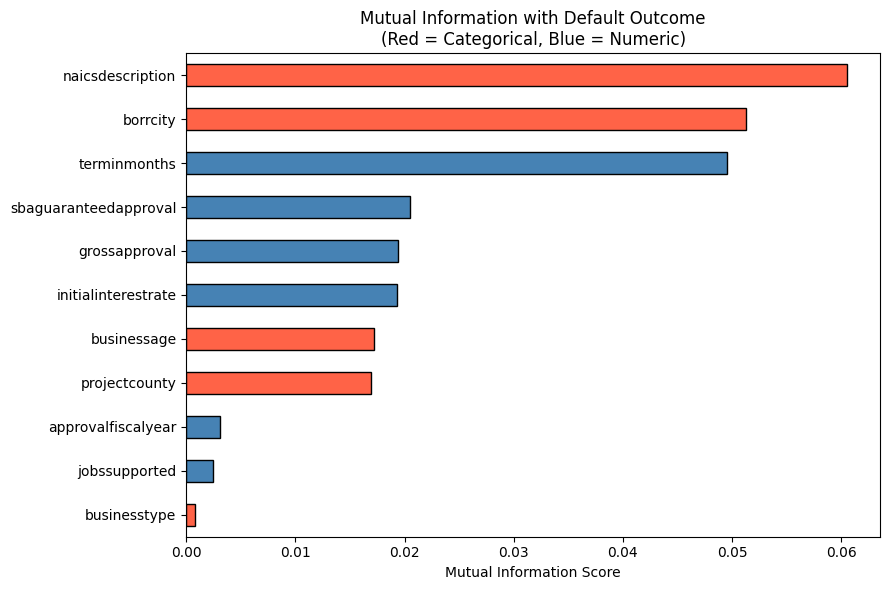


Mutual Information Rankings (High → Low):
------------------------------------------------
  naicsdescription               MI = 0.0605  (categorical)
  borrcity                       MI = 0.0513  (categorical)
  terminmonths                   MI = 0.0496  (numeric)
  sbaguaranteedapproval          MI = 0.0205  (numeric)
  grossapproval                  MI = 0.0194  (numeric)
  initialinterestrate            MI = 0.0193  (numeric)
  businessage                    MI = 0.0172  (categorical)
  projectcounty                  MI = 0.0170  (categorical)
  approvalfiscalyear             MI = 0.0031  (numeric)
  jobssupported                  MI = 0.0025  (numeric)
  businesstype                   MI = 0.0008  (categorical)


In [12]:
# ============================================
# SECTION 6: Mutual Information
# Goal: Capture non-linear relationships
#       including categorical features
# ============================================

def mutual_info_with_target(df, feature_col, target_col):
    if df[feature_col].dtype == 'object':
        le = LabelEncoder()
        x = le.fit_transform(df[feature_col].fillna('Unknown'))
    else:
        x = pd.qcut(df[feature_col].fillna(0), q=10,
                    labels=False, duplicates='drop')
    return mutual_info_score(x, df[target_col])

all_features = NUMERIC_COLS + CATEGORICAL_COLS
mi_scores = {col: mutual_info_with_target(model_df, col, TARGET)
             for col in all_features}

mi_df = pd.Series(mi_scores).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if col in CATEGORICAL_COLS else 'steelblue'
          for col in mi_df.index]
mi_df.plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information with Default Outcome\n'
          '(Red = Categorical, Blue = Numeric)')
plt.tight_layout()
plt.show()

print("\nMutual Information Rankings (High → Low):")
print("-" * 48)
for feat, score in mi_df.sort_values(ascending=False).items():
    kind = 'categorical' if feat in CATEGORICAL_COLS else 'numeric'
    print(f"  {feat:<30} MI = {score:.4f}  ({kind})")